# Notes 31/3/2025

## Dashboards in Python

#### Import Our Data

In [3]:
import pandas as pd

cd = pd.read_csv('CleanClassData.csv')

#### Get Words From 'WinterBreak' Variable

In [4]:
winter = cd['WinterBreak'].str.cat(sep = ' ')

#### Wordcloud

In [5]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

words = WordCloud(scale = 3, background_color = 'white', colormap = 'viridis').generate(winter)

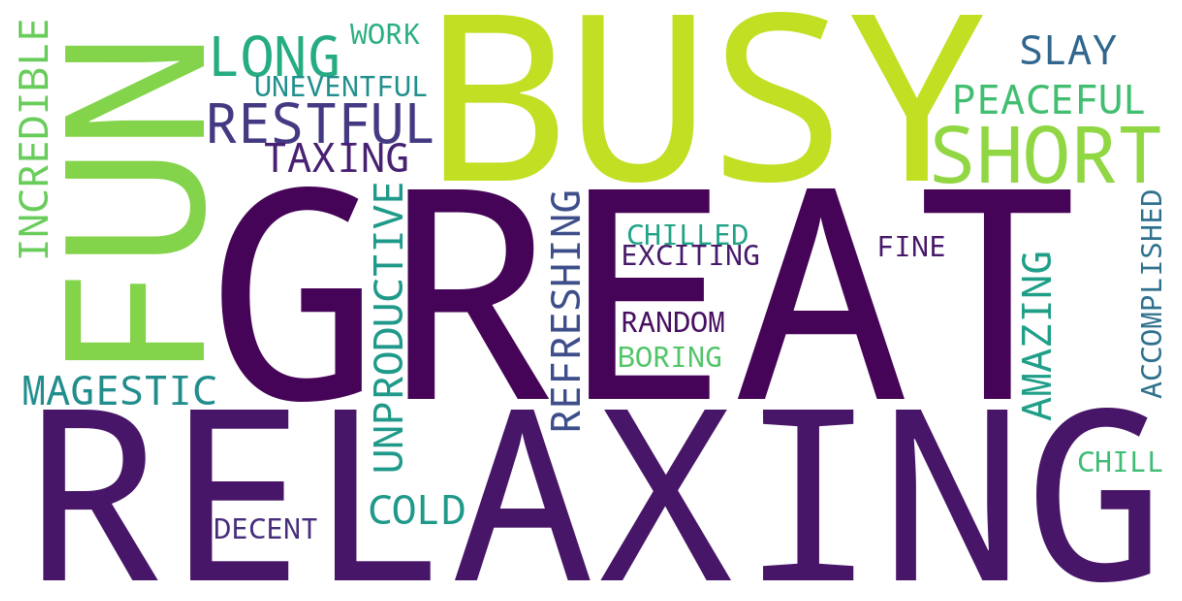

In [6]:
plt.figure(figsize = (15, 10))
plt.imshow(words, interpolation = 'bilinear')
plt.axis('off')
plt.show()

#### Now Building a Dashboard

In [7]:
import dash
from dash import dcc, html, Dash, Input, Output

In [8]:
cat_vars = cd.select_dtypes(include = ['object']).columns.tolist()

#### Layout

In [9]:
app=Dash()
app.title = 'Displaying Out Cat Data'

app.layout = html.Div([
    html.H1("WordCloud of our Cat Variables"),
    html.Div([
        html.Label("Select a Categorical Variable:"),
        dcc.Dropdown(id = "cat", 
                     options = [{'Label':col, 'value':col} for col in cat_vars],
                     value = cat_vars[8])
                     
    ]),
    html.Img(id = 'WordCloud')
])

#### Update Function

In [10]:
from io import BytesIO
import webbrowser
import base64

@app.callback(
    Output("wordcloud", "src"),
    [Input("cat", "value")]
)

def update_wordcloud(selected):
    select = cd[selected].str.cat(sep = " ")
    words = WordCloud(scale = 3, background_color = 'white', colormap = 'viridis').generate(select)
    img = BytesIO()
    plt.figure(figsize = (15, 10))
    plt.imshow(words, interpolation = 'bilinear')
    plt.axis('off')
    plt.savefig(img, format = 'png')
    img.seek(0)
    encoded_image = base64.b64encode(img.getvalue()).decode()

    return f'data:image/png;base64,{encoded_image}'

if __name__ == '__main__': 
    webbrowser.open("http://127.0.0.1.8050/")
    app.run(debug = True)


    